In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('C:/Users/derek/Desktop/ml-mini-projects/customer-survival-analysis')


In [38]:
# Load data
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

In [39]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [41]:
# Check for empty 'Total Charges'
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


* Small number of rows with empty total charges. -> safe to drop them

In [42]:
# Drop rows with blank total drops
df.drop(df[df['TotalCharges'] == ' '].index, inplace=True)

# Convert 'TotalCharges' to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Convert chrun data to integer values
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customer id
df.drop('customerID', axis=1, inplace=True)

In [43]:
# Check shape
df.shape


(7032, 20)

In [44]:
# Check head
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [45]:
# Check types to be converted
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [46]:
# Extract Columns for future comparisons
df_contracts = df[['tenure', 'Churn', 'Contract']].copy()

#### Encode columns

In [47]:
from src.preprocessing import encode_columns
df = encode_columns(df)

df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,0,0,0,0,1


In [48]:
# Check shape and dtypes
df.shape

(7032, 31)

In [49]:
df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No inter

#### Plot **Kaplan-Meier Curve** 

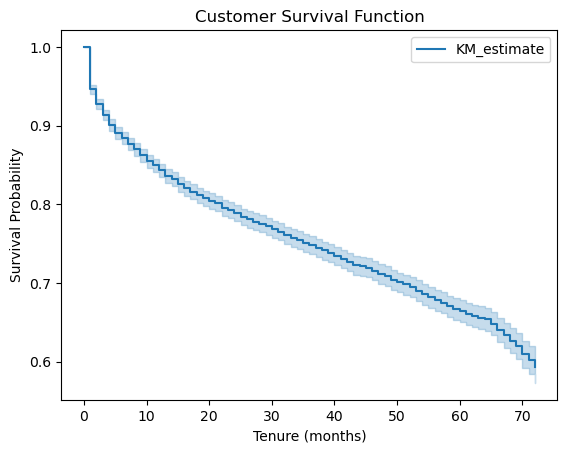

In [50]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fit and plot
kmf.fit(durations=df['tenure'], event_observed=df['Churn'])
kmf.plot_survival_function()
plt.title('Customer Survival Function')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.savefig('../visuals/survival_function.png')
plt.show()

#### Compare Contract Type

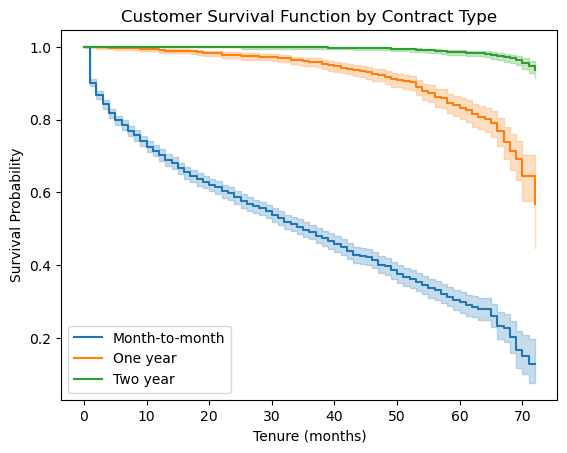

In [51]:
contract_types = df_contracts['Contract'].unique()

for contract in contract_types:
    mask = df_contracts['Contract'] == contract
    kmf.fit(durations=df_contracts[mask]['tenure'],
            event_observed=df_contracts[mask]['Churn'],
            label=contract)
    kmf.plot_survival_function()
plt.title('Customer Survival Function by Contract Type')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.savefig('../visuals/survival_function_contract.png')
plt.show()


The longer the contract, the less likely someone is to churn

### Cox Regression Model

In [55]:
from lifelines import CoxPHFitter

cpf = CoxPHFitter(penalizer=0.1)

# Drop TotalCharges to avoid perfect correlation error
df_cox = df.drop('TotalCharges', axis=1)

cpf.fit(df=df_cox, duration_col='tenure', event_col='Churn')
cpf.print_summary()

<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -14338.49
         time fit was run = 2026-03-07 02:49:40 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
gender                                -0.05      0.96      0.04           -0.12            0.03                0.88                1.03
SeniorCitizen                          0.01      1.01      0.05           -0.08            0.11                0.92                1.11
Partner                               -0.41      0.66      0.04           -0.50           -0.33                0.61                0.72
Dependents                            -0.16      0.86      0.05           -0.26           -0.06                0.77                0.95
PhoneService                           0.03      1.03      0.10           -0.16            0.23                0.85                1.26
PaperlessBilling                       0.18      1.20      0.04            0.09            0.27                1.09                1.31
MonthlyCharges                        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MultipleLines_No phone service        -0.03      0.97      0.10           -0.23            0.16                0.80                1.18
MultipleLines_Yes                     -0.32      0.73      0.04           -0.40           -0.23                0.67                0.79
InternetService_Fiber optic            0.32      1.38      0.05            0.22            0.43                1.24                1.53
InternetService_No                    -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
OnlineSecurity_No internet service    -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
OnlineSecurity_Yes                    -0.54      0.58      0.05           -0.64           -0.44                0.53                0.64
OnlineBackup_No internet service      -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
OnlineBackup_Yes                      -0.50      0.61      0.04           -0.58           -0.41                0.56                0.66
DeviceProtection_No internet service  -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
DeviceProtection_Yes                  -0.32      0.72      0.04           -0.41           -0.23                0.66                0.79
TechSupport_No internet service       -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
TechSupport_Yes                       -0.43      0.65      0.05           -0.53           -0.34                0.59                0.71
StreamingTV_No internet service       -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
StreamingTV_Yes                       -0.09      0.92      0.05           -0.18           -0.00                0.84                1.00
StreamingMovies_No internet service   -0.19      0.83      0.09           -0.36           -0.02                0.70                0.98
StreamingMovies_Yes                   -0.13      0.88      0.05           -0.22           -0.04                0.80                0.96
Contract_One year                     -0.82      0.44      0.06           -0.93           -0.71                0.39                0.49
Contract_Two year                  

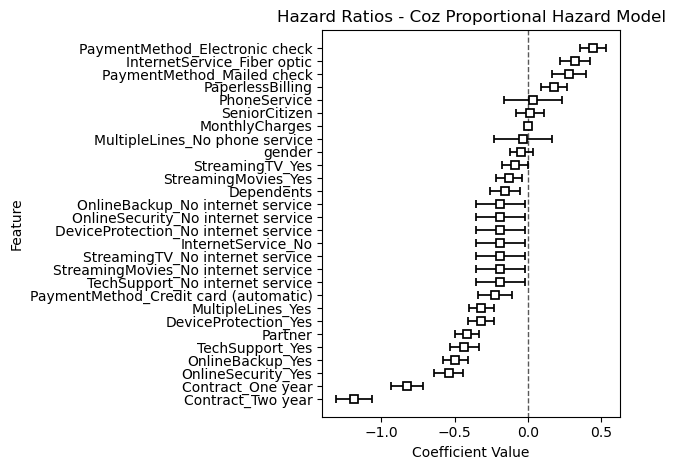

In [59]:
# Plot cpf
cpf.plot()
plt.title('Hazard Ratios - Coz Proportional Hazard Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.savefig('../visuals/cox_coefficients.png')
plt.tight_layout()
plt.show()

#### Prediction survival curve for specific customer profile

In [60]:
df_cox.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Churn',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [62]:
# Create customer profiles for high and low risk of churn based on CoxPHFitter results
high_risk = pd.DataFrame({
    'gender': [1],
    'SeniorCitizen': [0],
    'Partner': [0],
    'Dependents': [0],
    'tenure': [0],
    'PhoneService': [1],
    'PaperlessBilling': [1],
    'MonthlyCharges': [85.0],
    'Churn': [0],
    'MultipleLines_No phone service': [0],
    'MultipleLines_Yes': [0],
    'InternetService_Fiber optic': [1],
    'InternetService_No': [0],
    'OnlineSecurity_No internet service': [0],
    'OnlineSecurity_Yes': [0],
    'OnlineBackup_No internet service': [0],
    'OnlineBackup_Yes': [0],
    'DeviceProtection_No internet service': [0],
    'DeviceProtection_Yes': [0],
    'TechSupport_No internet service': [0],
    'TechSupport_Yes': [0],
    'StreamingTV_No internet service': [0],
    'StreamingTV_Yes': [1],
    'StreamingMovies_No internet service': [0],
    'StreamingMovies_Yes': [1],
    'Contract_One year': [0],
    'Contract_Two year': [0],
    'PaymentMethod_Credit card (automatic)': [0],
    'PaymentMethod_Electronic check': [1],
    'PaymentMethod_Mailed check': [0],
})

low_risk = pd.DataFrame({
    'gender': [1],
    'SeniorCitizen': [0],
    'Partner': [1],
    'Dependents': [1],
    'tenure': [0],
    'PhoneService': [1],
    'PaperlessBilling': [0],
    'MonthlyCharges': [55.0],
    'Churn': [0],
    'MultipleLines_No phone service': [0],
    'MultipleLines_Yes': [1],
    'InternetService_Fiber optic': [0],
    'InternetService_No': [0],
    'OnlineSecurity_No internet service': [0],
    'OnlineSecurity_Yes': [1],
    'OnlineBackup_No internet service': [0],
    'OnlineBackup_Yes': [1],
    'DeviceProtection_No internet service': [0],
    'DeviceProtection_Yes': [1],
    'TechSupport_No internet service': [0],
    'TechSupport_Yes': [1],
    'StreamingTV_No internet service': [0],
    'StreamingTV_Yes': [0],
    'StreamingMovies_No internet service': [0],
    'StreamingMovies_Yes': [0],
    'Contract_One year': [0],
    'Contract_Two year': [1],
    'PaymentMethod_Credit card (automatic)': [1],
    'PaymentMethod_Electronic check': [0],
    'PaymentMethod_Mailed check': [0],
})


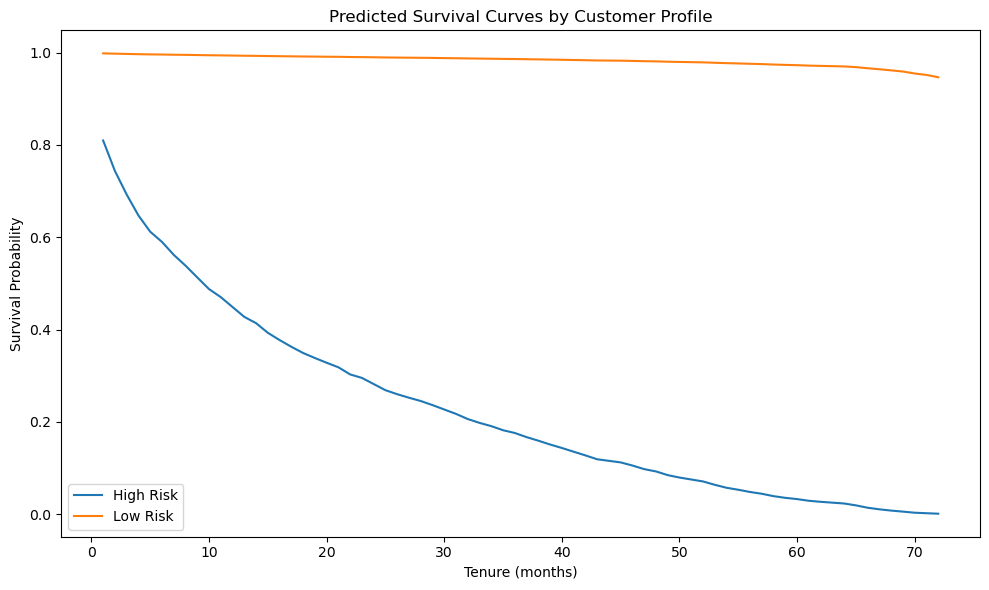

In [71]:
# Plot predicted survival curves for high and low risk profiles
plt.figure(figsize=(10, 6))
cpf.predict_survival_function(high_risk, times=range(1, 73)).plot(ax=plt.gca(), label='High Risk')
cpf.predict_survival_function(low_risk, times=range(1, 73)).plot(ax=plt.gca(), label='Low Risk')
plt.title('Predicted Survival Curves by Customer Profile')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.legend(['High Risk', 'Low Risk'])
plt.tight_layout()
plt.savefig('../visuals/survival_curves_profiles.png')
plt.show()

